In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
from functools import partial 
import torch
from torch.utils.data import (
    DataLoader,
    Dataset,
    Subset,
)
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchvision.transforms import functional

import diffusion_process as dfp
from score_model import ScoreNet
from diffusion_model import DiffusionModel

from diffusion_utilities import (
    plot_image_grid,
    plot_image_evolution,
    animation_images,
)
from integrators import (
    euler_maruyama as eu, 
    predictor_corrector as pc,
    probability_flow_ode as pfo
    )

device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Variance Exploding (VE)

In [2]:
ve_linear = DiffusionModel(
    type="VE",
    schedule="linear",
    sigma=25.0,
    sigma_min=0.01,
    sigma_max=25.0,
)
sigma_t_linear = ve_linear.sigma_t
diffusion_linear = ve_linear.diffusion

#### 1. Linear

In [3]:
#Create the net
score_model = torch.nn.DataParallel(ScoreNet(marginal_prob_std=sigma_t_linear))
score_model.to(device)

#Load the trained model
score_model.load_state_dict(torch.load("trained_models/ve_linear.pth", map_location=device))
score_model.eval()

#Initial Noise
n_images = 5
T = 1.0
image_T = torch.randn(n_images, 1, 28, 28, device=device)

- Euler-Maruyama integrator

In [4]:
drift_backward_ve_linear = ve_linear.get_backward_drift(score_model)
with torch.no_grad():
    times, synthetic_images_t = eu.euler_maruyama_integrator(
        image_T,
        t_0=T,
        t_end=1.0e-3,
        n_steps=500,
        drift_coefficient=drift_backward_ve_linear,
        diffusion_coefficient=ve_linear.diffusion,
    )

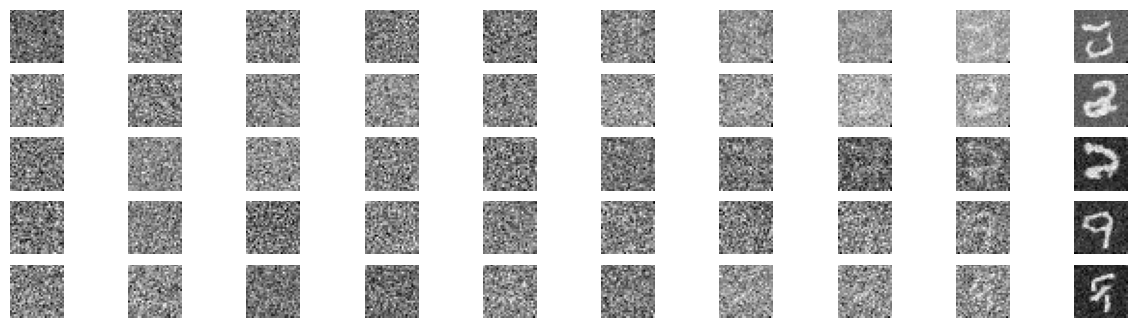

In [5]:
#Plot results
_ = plot_image_evolution(
    images=synthetic_images_t,
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

- Predictor Corrector

In [6]:
with torch.no_grad():
    times, synthetic_images_t_pc_linear = pc.predictor_corrector_integrator(
        x_0=image_T,
        t_0=T,
        t_end=1.0e-3,
        n_steps=500,
        backward_drift_coefficient=drift_backward_ve_linear,
        diffusion_coefficient=ve_linear.diffusion,
        score_model=score_model,
        corrector_steps=1,
        corrector_step_size=0.01,
        normalize_score=False,
    )

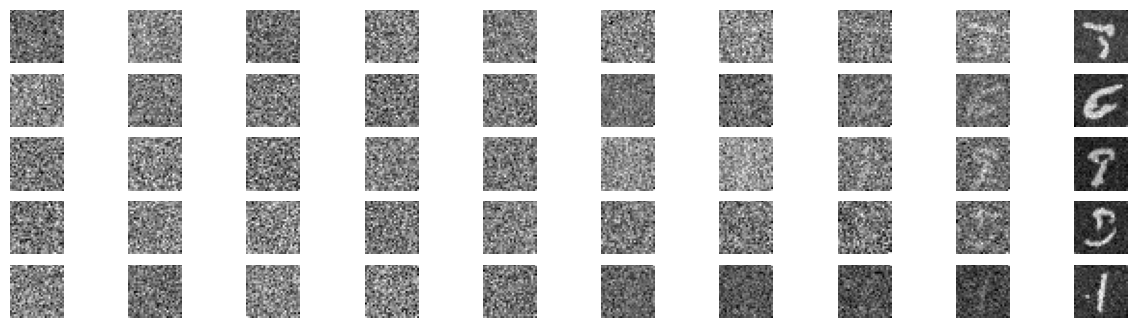

In [7]:
#Plot results
_ = plot_image_evolution(
    images=synthetic_images_t_pc_linear.detach().cpu(),
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

- Probability Flow ODE

In [8]:
ode_drift_ve_linear = ve_linear.get_probability_flow_drift(score_model)
with torch.no_grad():
    times_ode, synthetic_images_t_ode = pfo.probability_flow_ode_integrator(
        x_0=image_T,
        t_0=T,
        t_end=1.0e-3,
        n_steps=500,
        ode_drift_coefficient=ode_drift_ve_linear,
    )

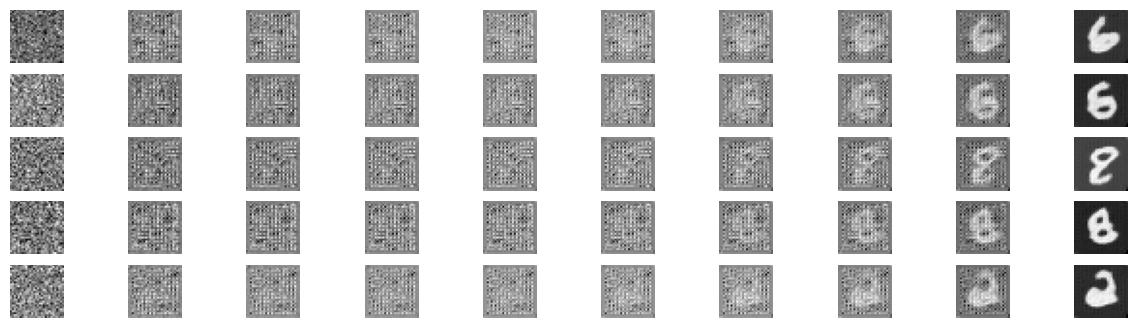

In [9]:
_ = plot_image_evolution(
    images=synthetic_images_t_ode,
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

#### 2. Cosine 

In [10]:
ve_cosine = DiffusionModel(
    type="VE",
    schedule="cosine",
    s=0.008,
)

sigma_t_cosine = ve_cosine.sigma_t
diffusion_coefficient_cosine = ve_cosine.diffusion


In [11]:
#Create the net
score_model_cosine = torch.nn.DataParallel(ScoreNet(marginal_prob_std=sigma_t_cosine))
score_model_cosine.to(device)

#Load the trained model
score_model_cosine.load_state_dict(torch.load("trained_models/ve_cosine.pth", map_location=device))
_ = score_model_cosine.eval()

- Euler-Maruyama integrator

In [12]:
drift_backward_ve_cosine = ve_cosine.get_backward_drift(score_model_cosine)
times_cosine, synthetic_images_t_cosine = eu.euler_maruyama_integrator(
    image_T,
    t_0=T,
    t_end=1.0e-3,
    n_steps=500,
    drift_coefficient=drift_backward_ve_cosine,
    diffusion_coefficient=diffusion_coefficient_cosine,
)
synthetic_images_t_cosine = synthetic_images_t_cosine.detach().cpu()

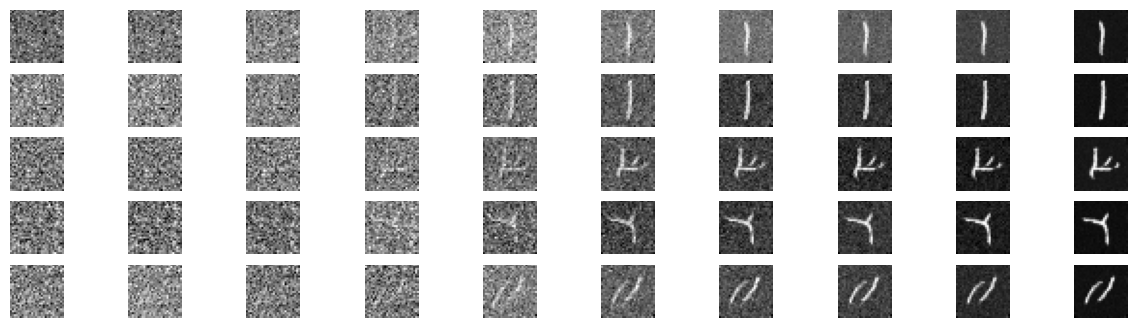

In [13]:
#Plot results
_ = plot_image_evolution(
    images=synthetic_images_t_cosine,
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

- Predictor Corrector

In [14]:
times, synthetic_images_t_pc_cosine = pc.predictor_corrector_integrator(
    x_0=image_T,
    t_0=T,
    t_end=1.0e-3,
    n_steps=500,
    backward_drift_coefficient=drift_backward_ve_cosine,
    diffusion_coefficient=diffusion_coefficient_cosine,
    score_model=score_model_cosine,
    corrector_steps=1,
    corrector_step_size=0.0001,
    normalize_score=False,
)

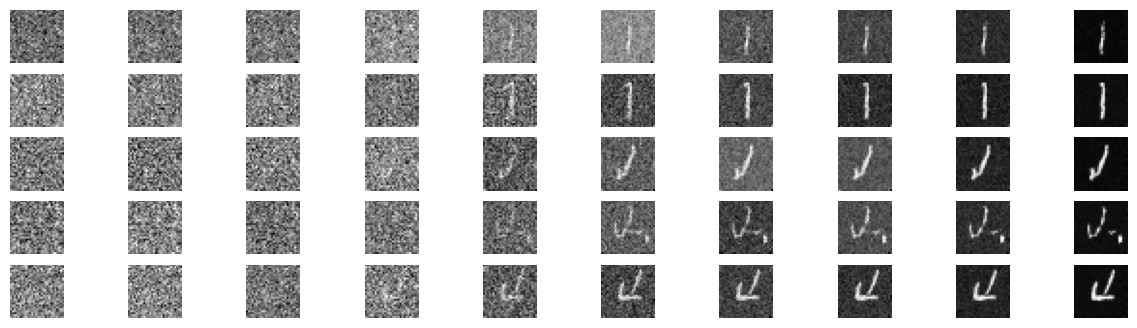

In [15]:
#Plot results
_ = plot_image_evolution(
    images=synthetic_images_t_pc_cosine.detach().cpu(),
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

- Probability Flow ODE

In [16]:
ode_drift_ve_cosine = ve_cosine.get_probability_flow_drift(score_model_cosine)
times_ode, synthetic_images_t_ode_cosine = pfo.probability_flow_ode_integrator(
    x_0=image_T,
    t_0=T,
    t_end=1.0e-3,
    n_steps=500,
    ode_drift_coefficient=ode_drift_ve_cosine,
)

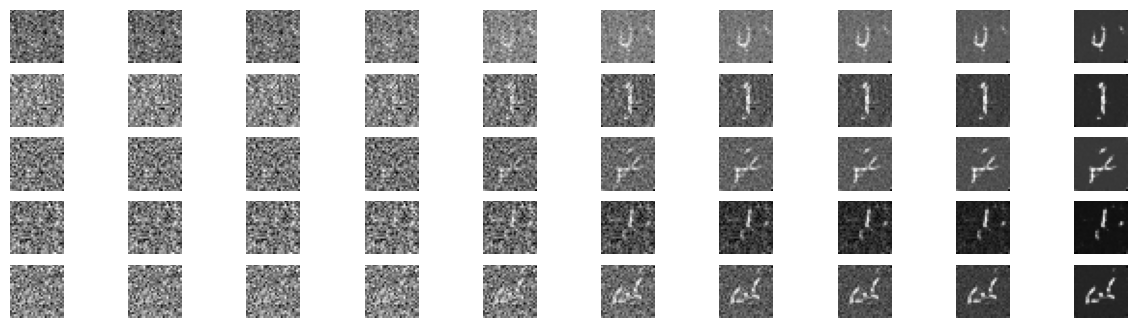

In [17]:
_ = plot_image_evolution(
    images=synthetic_images_t_ode_cosine.detach().cpu(),
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

## Variance Preserving (VP)

#### 1. Linear

In [18]:
vp_linear = DiffusionModel(
    type="VP",
    schedule="linear",
    beta_min=0.1,
    beta_max=20.0,
)

In [19]:
#Create the net
score_model_vp_linear = ScoreNet(marginal_prob_std=vp_linear.sigma_t)
score_model_vp_linear.to(device)

#Load the trained model
score_model_vp_linear.load_state_dict(torch.load("trained_models/vp_linear.pth", map_location=device))
_ = score_model_vp_linear.eval()

- Euler-Maruyama integrator

In [20]:
drift_backward_vp_linear = vp_linear.get_backward_drift(score_model_vp_linear)
with torch.no_grad():
    times_vp_linear, synthetic_images_t_vp_linear = eu.euler_maruyama_integrator(
        image_T,
        t_0=T,
        t_end=1.0e-3,
        n_steps=500,
        drift_coefficient=drift_backward_vp_linear,
        diffusion_coefficient=vp_linear.diffusion,
    )

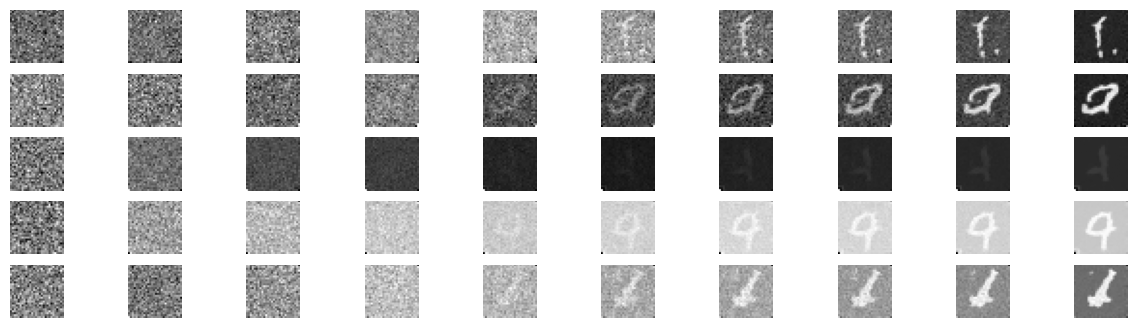

In [21]:
#Plot results
_ = plot_image_evolution(
    images=synthetic_images_t_vp_linear,
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

- Predictor Corrector

In [22]:
with torch.no_grad():
    times, synthetic_images_t_pc_vp_linear = pc.predictor_corrector_integrator(
        x_0=image_T,
        t_0=T,
        t_end=1.0e-3,
        n_steps=500,
        backward_drift_coefficient=drift_backward_vp_linear,
        diffusion_coefficient=vp_linear.diffusion ,
        score_model=score_model_vp_linear,
        corrector_steps=1,
        corrector_step_size=0.001,
        normalize_score=False,
    )

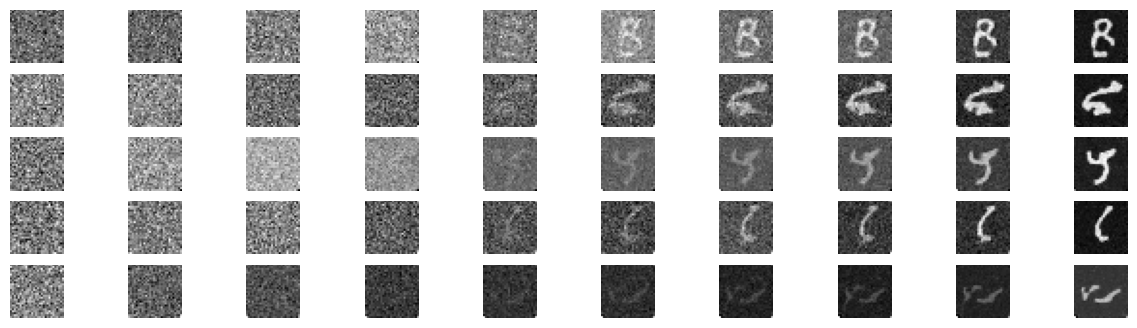

In [23]:
#Plot results
_ = plot_image_evolution(
    images=synthetic_images_t_pc_vp_linear.detach().cpu(),
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

- Probability Flow ODE

In [24]:
ode_drift_vp_linear = vp_linear.get_probability_flow_drift(score_model_vp_linear)
with torch.no_grad():
    times_ode, synthetic_images_t_ode_vp_linear = pfo.probability_flow_ode_integrator(
        x_0=image_T,
        t_0=T,
        t_end=1.0e-3,
        n_steps=500,
        ode_drift_coefficient=ode_drift_vp_linear,
    )

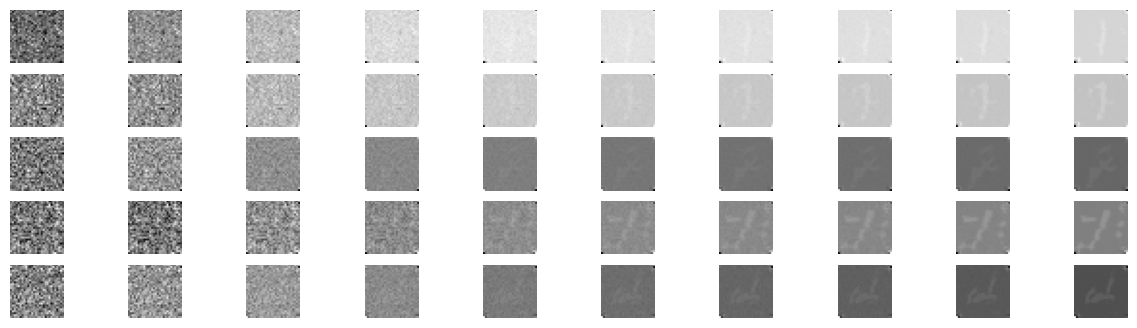

In [25]:
_ = plot_image_evolution(
    images=synthetic_images_t_ode_vp_linear,
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

#### 2. Cosine 

In [26]:
vp_cosine = DiffusionModel(
    type="VP",
    schedule="cosine",
    s=0.008,
)

sigma_t_cosinep = vp_cosine.sigma_t
diffusion_cosinep = vp_cosine.diffusion

In [27]:
#Create the net
score_model_vp_cosine = torch.nn.DataParallel(ScoreNet(marginal_prob_std=sigma_t_cosinep))
score_model_vp_cosine.to(device)

#Load the trained model
score_model_vp_cosine.load_state_dict(torch.load("trained_models/vp_cosine.pth", map_location=device))
_ = score_model_vp_cosine.eval()

- Euler-Maruyama integrator

In [28]:
drift_backward_vp_cosine = vp_cosine.get_backward_drift(score_model_vp_cosine)
T = 1.0 - 1e-3 #so it doesn't explode around one
with torch.no_grad():
    times_vp_cosine, synthetic_images_t_vp_cosine= eu.euler_maruyama_integrator(
        image_T,
        t_0=T,
        t_end=1.0e-3,
        n_steps=500,
        drift_coefficient=drift_backward_vp_cosine,
        diffusion_coefficient=vp_cosine.diffusion,
    )

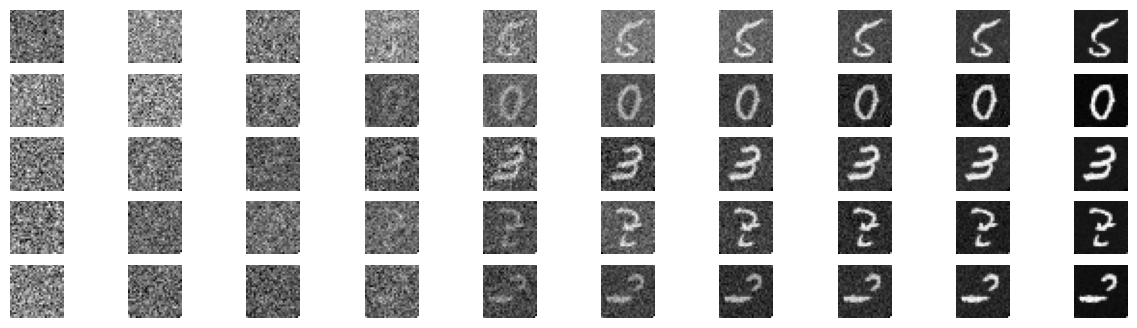

In [29]:
#Plot results
_ = plot_image_evolution(
    images=synthetic_images_t_vp_cosine,
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

- Predictor Corrector

In [30]:
with torch.no_grad():
    times, synthetic_images_t_pc_vp_cosine = pc.predictor_corrector_integrator(
        x_0=image_T,
        t_0=T,
        t_end=1.0e-3,
        n_steps=500,
        backward_drift_coefficient=drift_backward_vp_cosine,
        diffusion_coefficient=diffusion_cosinep ,
        score_model=score_model_vp_cosine,
        corrector_steps=1,
        corrector_step_size=0.001,
        normalize_score=False,
    )

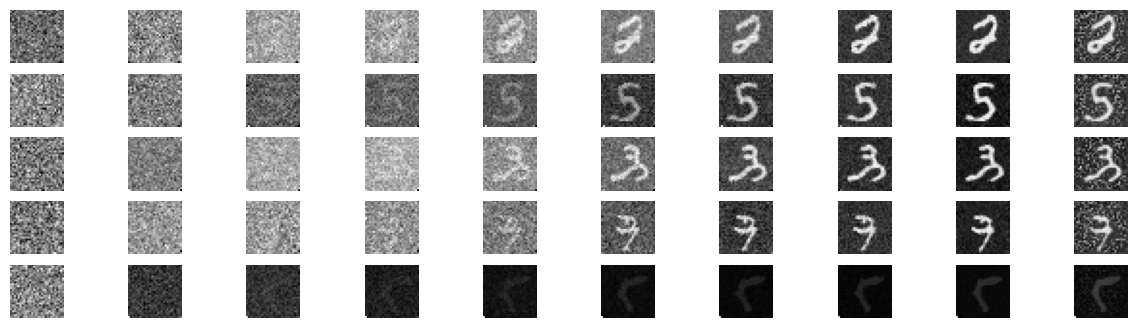

In [31]:
#Plot results
_ = plot_image_evolution(
    images=synthetic_images_t_pc_vp_cosine.detach().cpu(),
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

- Probability Flow ODE

In [32]:
ode_drift_vp_cosine = vp_cosine.get_probability_flow_drift(score_model_vp_cosine)
with torch.no_grad():
    times_ode, synthetic_images_t_ode_vp_cosine = pfo.probability_flow_ode_integrator(
        x_0=image_T,
        t_0=T,
        t_end=1.0e-3,
        n_steps=500,
        ode_drift_coefficient=ode_drift_vp_cosine,
    )

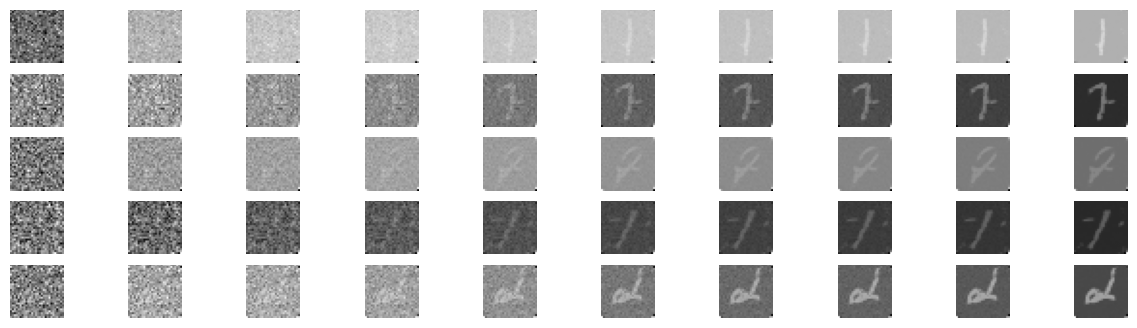

In [33]:
_ = plot_image_evolution(
    images=synthetic_images_t_ode_vp_cosine,
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)